# Genomics of Drug Sensitivity in Cancer (GDSC) — Analysis Notebook

In [1]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import seaborn as sns
import math
import tkinter as tk

In [2]:
# Define a helper function to dynamically adjust figure size based on screen resolution
def get_screen_size():
    # Get screen size
    root = tk.Tk()
    screen_width = root.winfo_screenwidth()
    screen_height = root.winfo_screenheight()
    root.destroy()

    # Calculate figure size (e.g., 70% of screen)
    dpi = 100
    fig_width = (screen_width * 0.7) / dpi
    fig_height = (screen_height * 0.7) / dpi

    return fig_width, fig_height

SCREEN_W, SCREEN_H = get_screen_size()
TARGET = "TARGET"

## 1. Data Loading

In [3]:
# Loading the GDSC Excel dataset into a Pandas DataFrame
gdsc = pd.read_excel('/Users/opemidimeji/Desktop/HackBio_AI_In_Genomics_Internship_2026/Stage One/Dataset/GDSC.xlsx')

## 2. Initial Dataset Inspection

In [4]:
# Display the first few rows of the dataset to preview its structure
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [5]:
# Display dataset information including column types and non-null counts
gdsc.info()

<class 'pandas.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  str    
 2   TCGA_DESC                                162103 non-null  str    
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  str    
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  str    
 9   GDSC Tissue descriptor 2                 162103 non-null  str    
 10  Cancer Type (matching TCGA label)        16

In [6]:
# Count the number of unique values in each column
gdsc.nunique()

COSMIC_ID                                     737
CELL_LINE_NAME                                737
TCGA_DESC                                      30
DRUG_ID                                       254
DRUG_NAME                                     246
LN_IC50                                    159646
AUC                                        109624
Z_SCORE                                    158203
GDSC Tissue descriptor 1                       17
GDSC Tissue descriptor 2                       33
Cancer Type (matching TCGA label)              30
Microsatellite instability Status (MSI)         2
Screen Medium                                   2
Growth Properties                               3
CNA                                             2
Gene Expression                                 2
Methylation                                     2
TARGET                                        183
TARGET_PATHWAY                                 23
dtype: int64

In [7]:
# Generate descriptive statistics for numerical variables
gdsc.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.621030e+05,162103.000000,162103.000000,162103.000000,162103.000000
mean,9.857634e+05,1554.527603,2.822644,0.879924,0.037711
std,2.240213e+05,406.964712,2.836231,0.148592,0.999098
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716
25%,9.059780e+05,1086.000000,1.476170,0.845967,-0.615884
50%,9.092570e+05,1598.000000,3.271447,0.941467,0.048930
75%,1.240143e+06,1910.000000,4.767629,0.973917,0.686466
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776


## 3. Data Quality Assessment

In [8]:
# Check for missing values across all columns
# check for missing values
gdsc.isnull().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [9]:
# Identify duplicate combinations of cell lines and drugs
# check for duplicates
gdsc.duplicated(subset=['CELL_LINE_NAME', 'DRUG_NAME']).sum()

np.int64(4290)

In [10]:
# Examine whether duplicate drug-cell line pairs differ in other biological variables
#Checking for variations in the other columns for the duplicate combinations
cols_to_check = [
    'Microsatellite instability Status (MSI)',
    'CNA',
    'Gene Expression',
    'Methylation',
    'Screen Medium',
    'Growth Properties',
    'TARGET',
    'TARGET_PATHWAY',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Cancer Type (matching TCGA label)'
]

gdsc.groupby(['COSMIC_ID', 'DRUG_NAME'])[cols_to_check].nunique().max()

Microsatellite instability Status (MSI)    1
CNA                                        1
Gene Expression                            1
Methylation                                1
Screen Medium                              1
Growth Properties                          1
TARGET                                     1
TARGET_PATHWAY                             1
GDSC Tissue descriptor 1                   1
GDSC Tissue descriptor 2                   1
Cancer Type (matching TCGA label)          1
dtype: int64

We observed that there are **737** unique **COSMIC_ID** and **246** unique **DRUG_NAME**. The possible combination of all DRUG_NAME and COMIC_ID of cell lines will give a total **181302** entries, but in our dataset we have have only **162103** entries. This mean that not all drug were tested on every cell line. We checked if all combination of cell line and drug name were unique and we found that there were 4290 duplicated combination of cell line and drug name. We went further to check if other features were unique for the duplicated observations. This led to the confirmation that they are actually duplicates rather than seperate experiments. Upon further investigations, we found out that there a possibility that data were collected from different experiments which vary owing  to the different sensitivity metrics. Therefore, rather than deleting the duplicates we've decided to keep them.

In [11]:
# Compare whether TCGA_DESC matches the TCGA cancer label column
(gdsc['TCGA_DESC'] == gdsc['Cancer Type (matching TCGA label)']).all()

np.False_

In [12]:
gdsc[['TCGA_DESC', 'Cancer Type (matching TCGA label)']].head(100)

,TCGA_DESC,Cancer Type (matching TCGA label)
0,MB,MB
1,SKCM,SKCM
2,BLCA,BLCA
3,BLCA,BLCA
4,BLCA,BLCA
...,...,...
95,BLCA,BLCA
96,LUSC,LUSC
97,ESCA,ESCA
98,LUSC,LUSC


In [13]:
# Extract rows where TCGA_DESC differs from the matching TCGA cancer label
mask = gdsc['TCGA_DESC'] != gdsc['Cancer Type (matching TCGA label)']

gdsc.loc[mask, ['TCGA_DESC', 'Cancer Type (matching TCGA label)']]

,TCGA_DESC,Cancer Type (matching TCGA label)
145,COREAD,COAD/READ
146,COREAD,COAD/READ
148,COREAD,COAD/READ
168,COREAD,COAD/READ
169,COREAD,COAD/READ
...,...,...
162009,COREAD,COAD/READ
162099,COREAD,COAD/READ
162100,COREAD,COAD/READ
162101,COREAD,COAD/READ


# Exploratory Data Analysis

## Univariate Analysis

### Continuous Variables

In [14]:
# Generate visualization for exploratory data analysis
def plot_distribution(data: pd.DataFrame = None, columns: list[str] = None):
    if data is None or columns is None:
        print("Missing dataframe or columns")
        return

    n = len(columns)
    n_cols = min(n, 3)
    n_rows = math.ceil(n / n_cols)

    figure = plt.figure(figsize=(SCREEN_W, SCREEN_H / n))
    outer_grid = GridSpec(n_rows, n_cols, wspace=.25, hspace=.35)
    
    for i, column in enumerate(columns):
        r, c = divmod(i, n_cols)
        
        inner_grid = GridSpecFromSubplotSpec(
            nrows=2, 
            ncols=1, 
            subplot_spec=outer_grid[r, c],
            height_ratios=[3, 1],
            hspace=.05
        )

        # --- Histogram
        hist_axe = figure.add_subplot(inner_grid[0])
        sns.histplot(data[column], bins=30, ax=hist_axe, color='skyblue')

        # Compute mean & median
        mean_val = data[column].mean()
        median_val = data[column].median()

        # Add vertical lines
        hist_axe.axvline(mean_val, color='blue', linestyle='--',
                         label=f'Mean: {mean_val:.2f}')
        hist_axe.axvline(median_val, color='red', linestyle='-',
                         label=f'Median: {median_val:.2f}')

        hist_axe.set_title(f"Distribution of {column}")
        hist_axe.set_xlabel("")
        hist_axe.legend()

        # --- Boxplot
        box_axe = figure.add_subplot(inner_grid[1])
        sns.boxplot(x=data[column].dropna(), ax=box_axe, color='skyblue')
        box_axe.set_xlabel(column)
        
    plt.show()

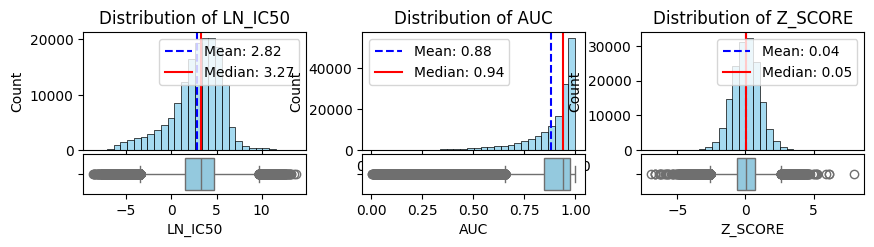

In [15]:
# Generate visualization for exploratory data analysis
continuous = gdsc.select_dtypes('float').columns
plot_distribution(data=gdsc, columns=continuous)

### Discrete / Categorical Variables

In [16]:
identifiers = ["COSMIC_ID", "DRUG_ID", "DRUG_NAME", "CELL_LINE_NAME"] + ["TARGET"]
discretes = gdsc.select_dtypes(exclude='float').columns.difference(identifiers)

In [17]:
# Generate visualization for exploratory data analysis
def plot_proportions(data: pd.DataFrame = None, columns: list[str] = None, show_pct=True, n_cols=3):
    if data is None or columns is None:
        print("Missing Dataframe or columns")
        return
    
    n = len(columns)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    
    figure, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(SCREEN_W, SCREEN_H * 1.5), constrained_layout=True)
    
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, column in enumerate(columns):
        value_counts = data[column].value_counts().sort_index()
        
        bars = axes[i].bar(
            value_counts.index.astype(str),
            value_counts.values,
            color="steelblue",
            edgecolor="black"
        )
        axes[i].set_title(column)
        axes[i].set_ylabel("Count")
        # axes[i].tick_params(axis="x", rotation=75)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(
            value_counts.index.astype(str),
            rotation=45,
            ha="right",
            fontsize=10
        )

        axes[i].set_ylim(0, value_counts.values.max() * 1.15)
        
        if show_pct:
            total = value_counts.sum()
            for bar, val in zip(bars, value_counts.values):
                pct = f"{(val / total) * 100:.1f}%"
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    pct,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=0,
                )
     # Hide unused subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)

    # remove plt.tight_layout() if using constrained_layout=True above, it's more robust
    plt.show()  

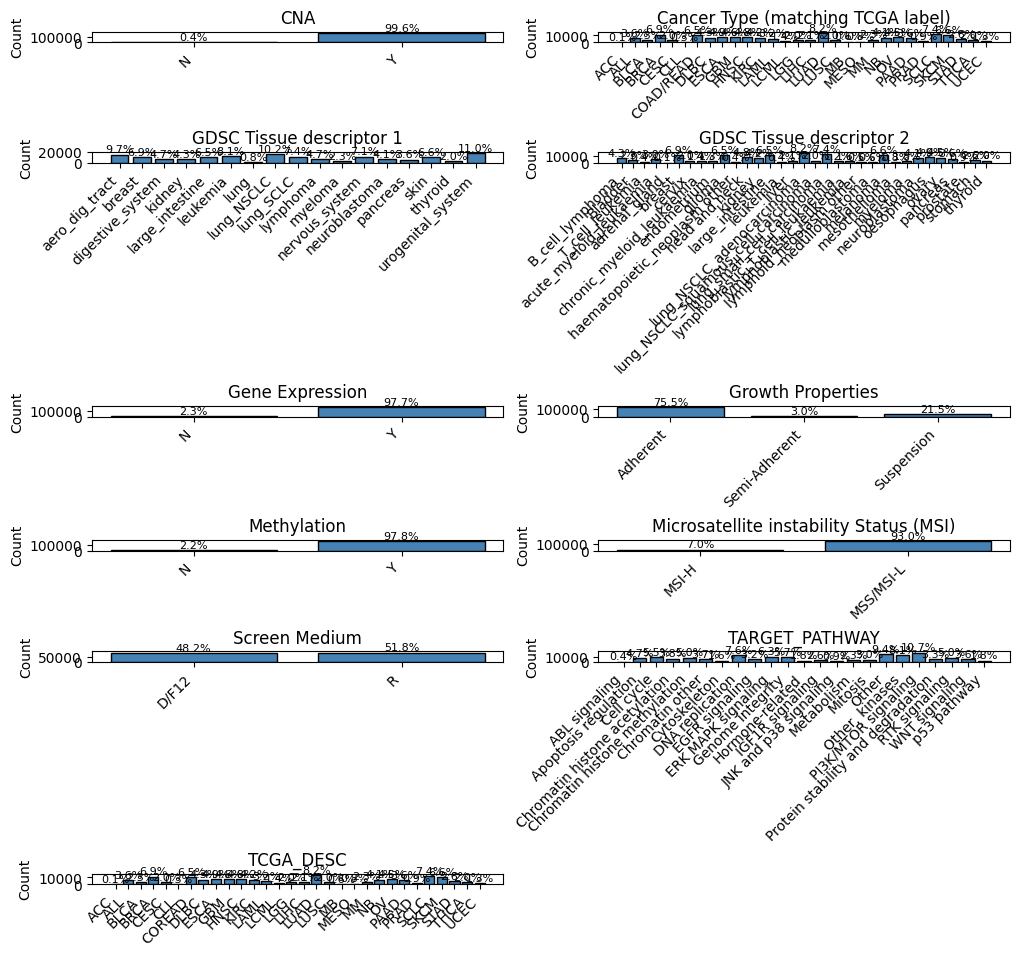

In [18]:
# Generate visualization for exploratory data analysis
plot_proportions(data=gdsc, columns=discretes, n_cols=2)

## Multivariate Analysis


### Continuous

In [19]:
# Generate visualization for exploratory data analysis
def plot_correlation(data: pd.DataFrame, columns: list, screen_w, screen_h, title="Correlation Matrix (Lower Triangle)"):
    """
    Plots correlation heatmap with the upper triangle masked.
    
    Parameters:
    - data: The dataframe containing the data.
    - columns: List of column names to include in the analysis. 
    - screen_w, screen_h: Figure dimensions.
    """
    
    if data is None or columns is None:
        print("❌ Missing dataframe or columns")
        return

    # 1. Calculate Correlation
    corr_matrix = data[columns].corr()

    # 2. Create a Mask for the Upper Triangle
    # np.triu returns the upper triangle of an array.
    # The mask should be True for the values you want to HIDE.
    # mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    mask = None

    # 3. Setup Plot 
    plt.figure(figsize=(screen_w, screen_h))
    plt.title(title)

    # 4. Render with Mask
    # Note: mask=mask argument hides the upper triangle
    sns.heatmap(corr_matrix, mask=mask, square=True, annot=True, cmap='coolwarm', center= 0, linewidths=0.5, fmt='.2f')
    
    plt.show()

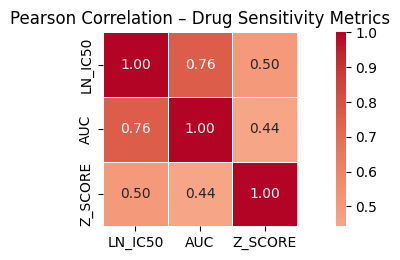

In [20]:
# Generate visualization for exploratory data analysis
plot_correlation(data=gdsc, columns=continuous, screen_h=SCREEN_H / 2.5, screen_w=SCREEN_W, title="Pearson Correlation – Drug Sensitivity Metrics")

### Discretes - Continuous

In [21]:
# Aggregate and summarize data across groups
drug_stats = (
    gdsc.groupby("DRUG_NAME")[["LN_IC50", "AUC", "Z_SCORE"]]
    .agg(["median", "std", "count"])
    .round(3)
)

drug_stats.columns = ["_".join(c) for c in drug_stats.columns]
drug_stats = drug_stats.reset_index()
drug_stats

,DRUG_NAME,LN_IC50_median,LN_IC50_std,LN_IC50_count,AUC_median,AUC_std,AUC_count,Z_SCORE_median,Z_SCORE_std,Z_SCORE_count
0,5-Fluorouracil,4.462,1.703,737,0.928,0.080,737,0.044,0.992,737
1,5-azacytidine,2.893,1.368,574,0.848,0.085,574,-0.069,0.985,574
2,A-366,4.927,1.016,574,0.971,0.019,574,0.054,0.991,574
3,ABT737,2.278,2.069,726,0.854,0.187,726,0.195,1.008,726
4,AGI-5198,4.712,0.915,727,0.969,0.018,727,0.013,1.012,727
...,...,...,...,...,...,...,...,...,...,...
241,YK-4-279,2.123,1.668,727,0.813,0.116,727,-0.073,1.011,727
242,ZM447439,2.538,1.704,715,0.872,0.102,715,-0.023,1.000,715
243,alpha-lipoic acid,7.705,1.002,572,0.976,0.017,572,0.057,1.038,572
244,ascorbate (vitamin C),10.450,1.288,567,0.977,0.034,567,0.156,1.005,567


## Drug Sensitivity Patterns

### Most Effective Drugs
We rank all drugs by **median LN_IC50 across all cell lines** and display the 15 most potent. These are drugs that inhibit 50 % of cell growth at the lowest concentration — candidates of high pharmacological interest.

Error bars (±1 SD) are shown to distinguish drugs that are universally potent from those that are potent only in a subset of cell lines.


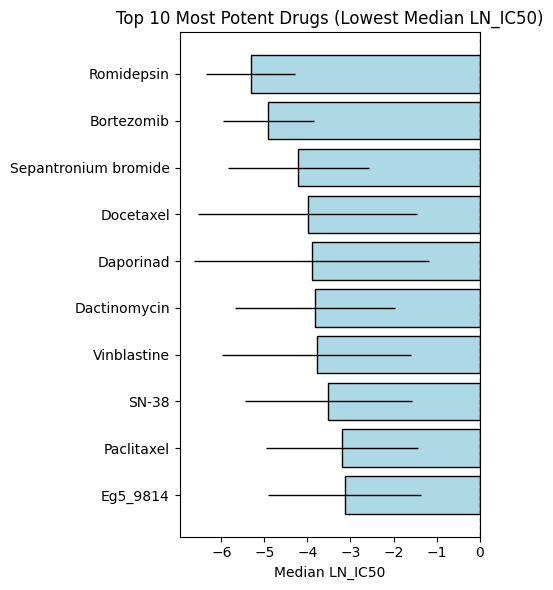

In [22]:
# Generate visualization for exploratory data analysis
top_effective = drug_stats.nsmallest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))
bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Most Potent Drugs (Lowest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

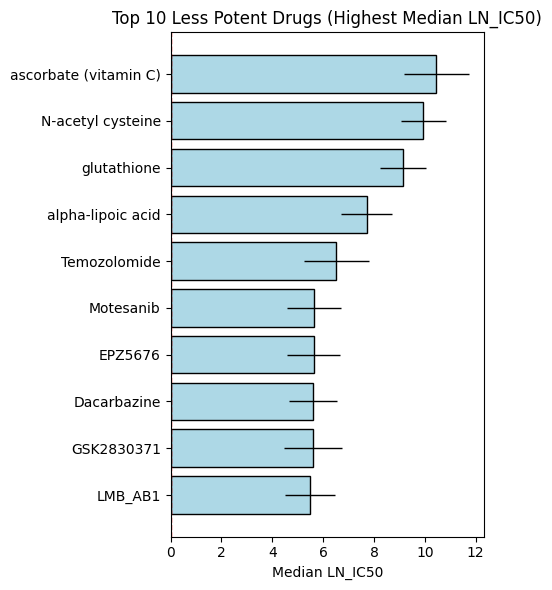

In [23]:
# Generate visualization for exploratory data analysis
top_effective = drug_stats.nlargest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))

bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")

ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Less Potent Drugs (Highest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Drugs with Highly Variable Response Across Cell Lines

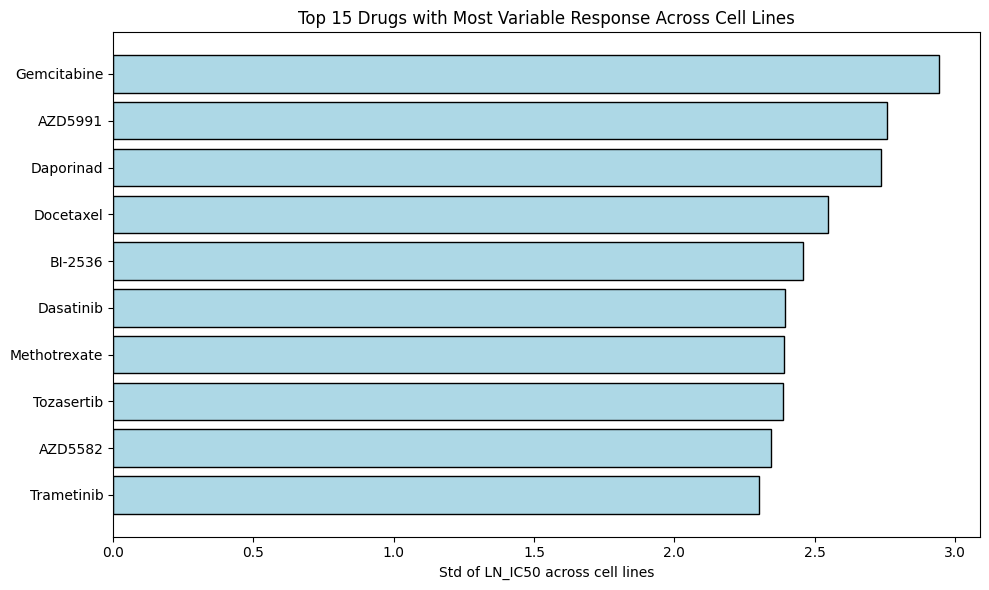

In [24]:
# Generate visualization for exploratory data analysis
top_variable = drug_stats.nlargest(10, "LN_IC50_std")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_variable["DRUG_NAME"], top_variable["LN_IC50_std"],
        color="lightblue", edgecolor="black")

ax.set_xlabel("Std of LN_IC50 across cell lines")
ax.set_title("Top 15 Drugs with Most Variable Response Across Cell Lines")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cancer Cell Line Analysis

In [25]:
# Aggregate and summarize data across groups
results = (
gdsc.groupby(["DRUG_NAME", "CELL_LINE_NAME"])["LN_IC50"]
.mean()
.reset_index()
.rename(columns={"LN_IC50": "MEAN_LN_IC50"})
)

In [26]:
results

,DRUG_NAME,CELL_LINE_NAME,MEAN_LN_IC50
0,5-Fluorouracil,22RV1,2.319251
1,5-Fluorouracil,23132-87,1.807592
2,5-Fluorouracil,42-MG-BA,3.463196
3,5-Fluorouracil,451Lu,3.910357
4,5-Fluorouracil,639-V,4.575843
...,...,...,...
157808,glutathione,YAPC,10.129067
157809,glutathione,YH-13,9.473305
157810,glutathione,YT,8.883967
157811,glutathione,ZR-75-30,11.193687


In [27]:
# Initialize an empty list to store results
# Each entry will represent the average drug response for a specific cell line
results = []

# Loop through each unique drug in the dataset
for drug in gdsc["DRUG_NAME"].unique():
    
    # Subset the dataset to include only rows for the current drug
    subset = gdsc[gdsc["DRUG_NAME"] == drug]
    
    # Loop through each unique cell line tested with this drug
    for cell in subset["CELL_LINE_NAME"].unique():
        
        # Further subset the data for the current cell line
        cell_data = subset[subset["CELL_LINE_NAME"] == cell]
        
        # Compute the mean LN_IC50 for this drug-cell line combination
        # LN_IC50 represents drug sensitivity (lower = more sensitive)
        mean_response = cell_data["LN_IC50"].mean()
        
        # Store the result as a dictionary
        # This structure makes it easy to convert into a DataFrame later
        results.append({
            "DRUG_NAME": drug,
            "CELL_LINE": cell,
            "MEAN_LN_IC50": mean_response
        })

# Convert the list of dictionaries into a pandas DataFrame
# Final table: each row = one drug–cell line pair with average response
cell_drug_df = pd.DataFrame(results)

cell_drug_df

,DRUG_NAME,CELL_LINE,MEAN_LN_IC50
0,Camptothecin,PFSK-1,-1.463887
1,Camptothecin,COLO-829,-1.235034
2,Camptothecin,RT4,-2.963191
3,Camptothecin,SW780,-1.449138
4,Camptothecin,TCCSUP,-2.350633
...,...,...,...
157808,N-acetyl cysteine,MM1S,9.316959
157809,N-acetyl cysteine,SNU-175,10.127082
157810,N-acetyl cysteine,SNU-407,8.576377
157811,N-acetyl cysteine,SNU-61,10.519636


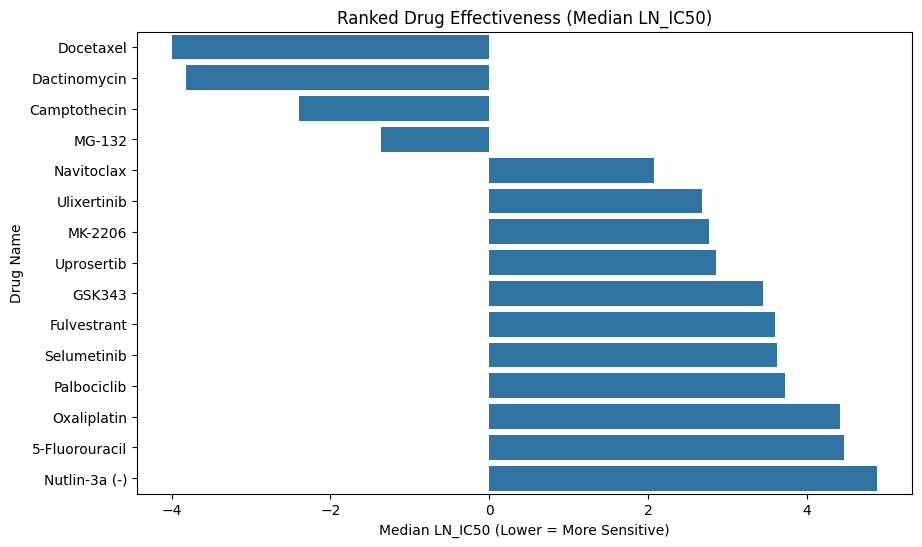

In [28]:
# Group the dataset by drug name and compute median LN_IC50
# This gives an overall measure of drug effectiveness across all cancer types
drug_response = gdsc.groupby("DRUG_NAME")["LN_IC50"].median()

# Select the top 15 most frequently tested drugs (to reduce noise)
top_drugs = gdsc["DRUG_NAME"].value_counts().head(15).index

# Filter only these drugs
drug_response = drug_response.loc[top_drugs]

# Sort values:
# Lower LN_IC50 = more effective → so sort ascending
drug_response = drug_response.sort_values(ascending=True)

# Create the plot
plt.figure(figsize=(10,6))

# Horizontal bar plot (best for ranking)
sns.barplot(
    x=drug_response.values,
    y=drug_response.index
)

# Add labels and title
plt.title("Ranked Drug Effectiveness (Median LN_IC50)")
plt.xlabel("Median LN_IC50 (Lower = More Sensitive)")
plt.ylabel("Drug Name")

# Show plot
plt.show()

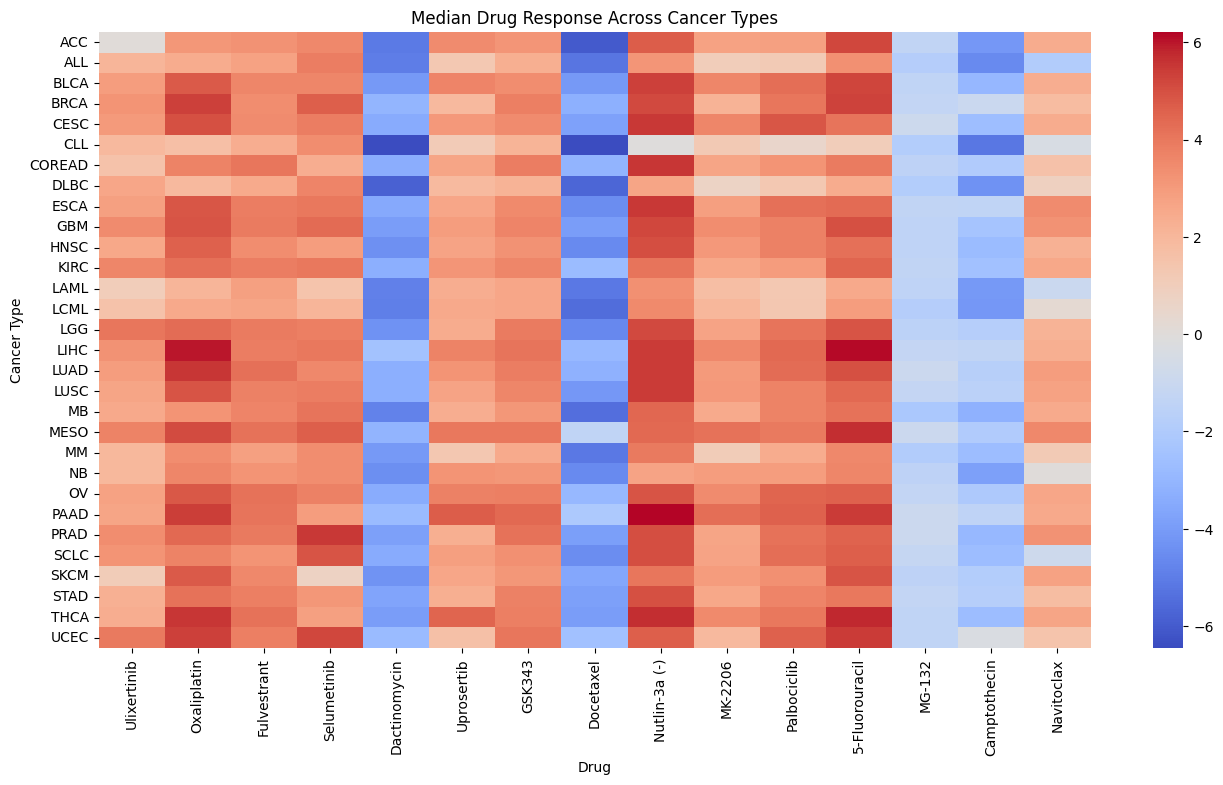

In [29]:

# Group the dataset by cancer type (TCGA_DESC) and drug name
# Then compute the median LN_IC50 for each combination
# Median is used instead of mean to reduce the effect of outliers
response_matrix = gdsc.groupby(
    ["TCGA_DESC", "DRUG_NAME"]
)["LN_IC50"].median().unstack()

# At this point:
# Rows   = Cancer types
# Columns = Drugs
# Values = Median drug response (LN_IC50)

# Optional step: select only the top 15 most frequently tested drugs
# This helps reduce noise and makes the heatmap easier to interpret
top_drugs = gdsc["DRUG_NAME"].value_counts().head(15).index

# Filter the response matrix to include only these top drugs
response_matrix = response_matrix[top_drugs]

# Create a figure with a larger size for better readability
plt.figure(figsize=(16,8))

# Plot the heatmap
# Each cell represents the median LN_IC50 for a drug-cancer combination
# "coolwarm" color map:
#   - Cool colors (blue) → lower LN_IC50 → higher drug sensitivity
#   - Warm colors (red) → higher LN_IC50 → lower sensitivity (resistance)
sns.heatmap(response_matrix, cmap="coolwarm")

# Add descriptive title and axis labels
plt.title("Median Drug Response Across Cancer Types")
plt.xlabel("Drug")
plt.ylabel("Cancer Type")

# Display the plot
plt.show()

### LN_IC50 Distribution by Cancer Type

A **box plot sorted by median LN_IC50** lets us rank cancer types from most drug-sensitive (left) to most drug-resistant (right) globally. The red dashed line marks the overall median across all rows, serving as a neutral reference point.

Note that this global view aggregates across all drugs — a cancer type that appears resistant overall may still harbour a narrow but targetable sensitivity to specific agents (explored in the heatmap and selective sensitivity analysis below).


/var/folders/bf/dgs_1xq14h1_m_71khkmjfqc0000gn/T/ipykernel_96062/530419225.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x="TCGA_DESC", y="LN_IC50", order=cancer_order,
/var/folders/bf/dgs_1xq14h1_m_71khkmjfqc0000gn/T/ipykernel_96062/530419225.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)


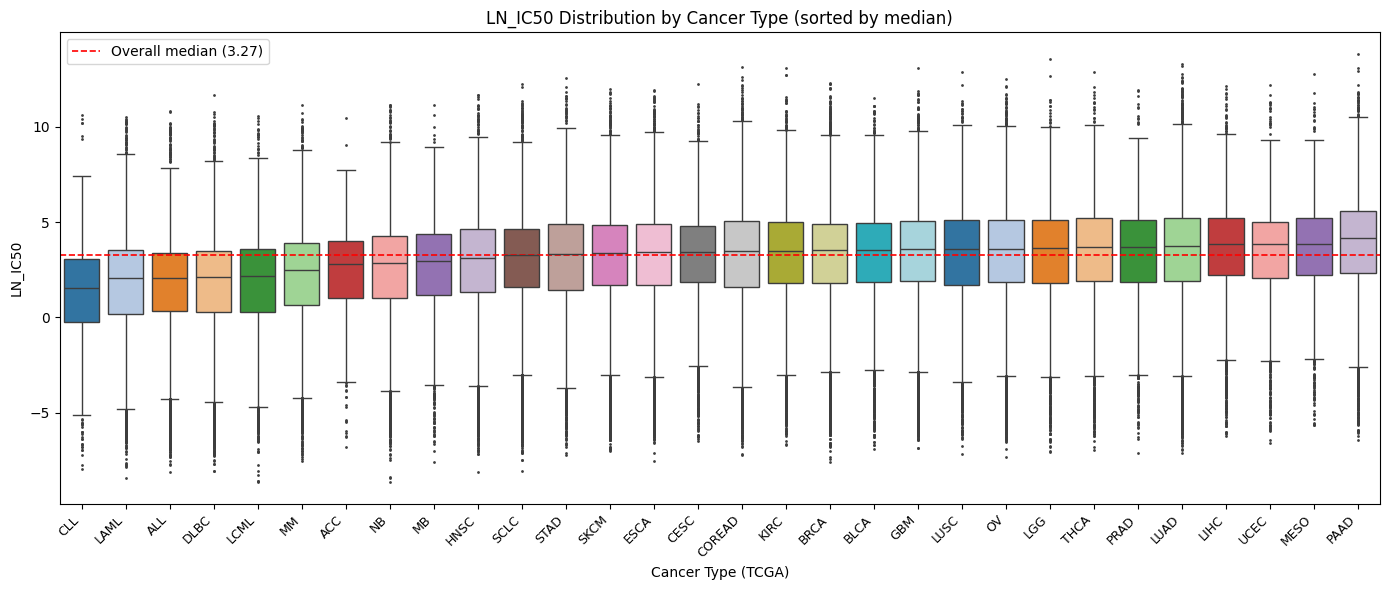

In [30]:
# Generate visualization for exploratory data analysis
cancer_order = (
    gdsc.groupby(["TCGA_DESC"])["LN_IC50"]
    .median()
    .sort_values()
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=gdsc, x="TCGA_DESC", y="LN_IC50", order=cancer_order,
            palette="tab20", fliersize=1, ax=ax)

ax.axhline(gdsc["LN_IC50"].median(), color="red", linestyle="--",
           linewidth=1.2, label=f"Overall median ({gdsc['LN_IC50'].median():.2f})")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_title("LN_IC50 Distribution by Cancer Type (sorted by median)")
ax.set_xlabel("Cancer Type (TCGA)")
ax.set_ylabel("LN_IC50")
ax.legend()
plt.tight_layout()
plt.show()

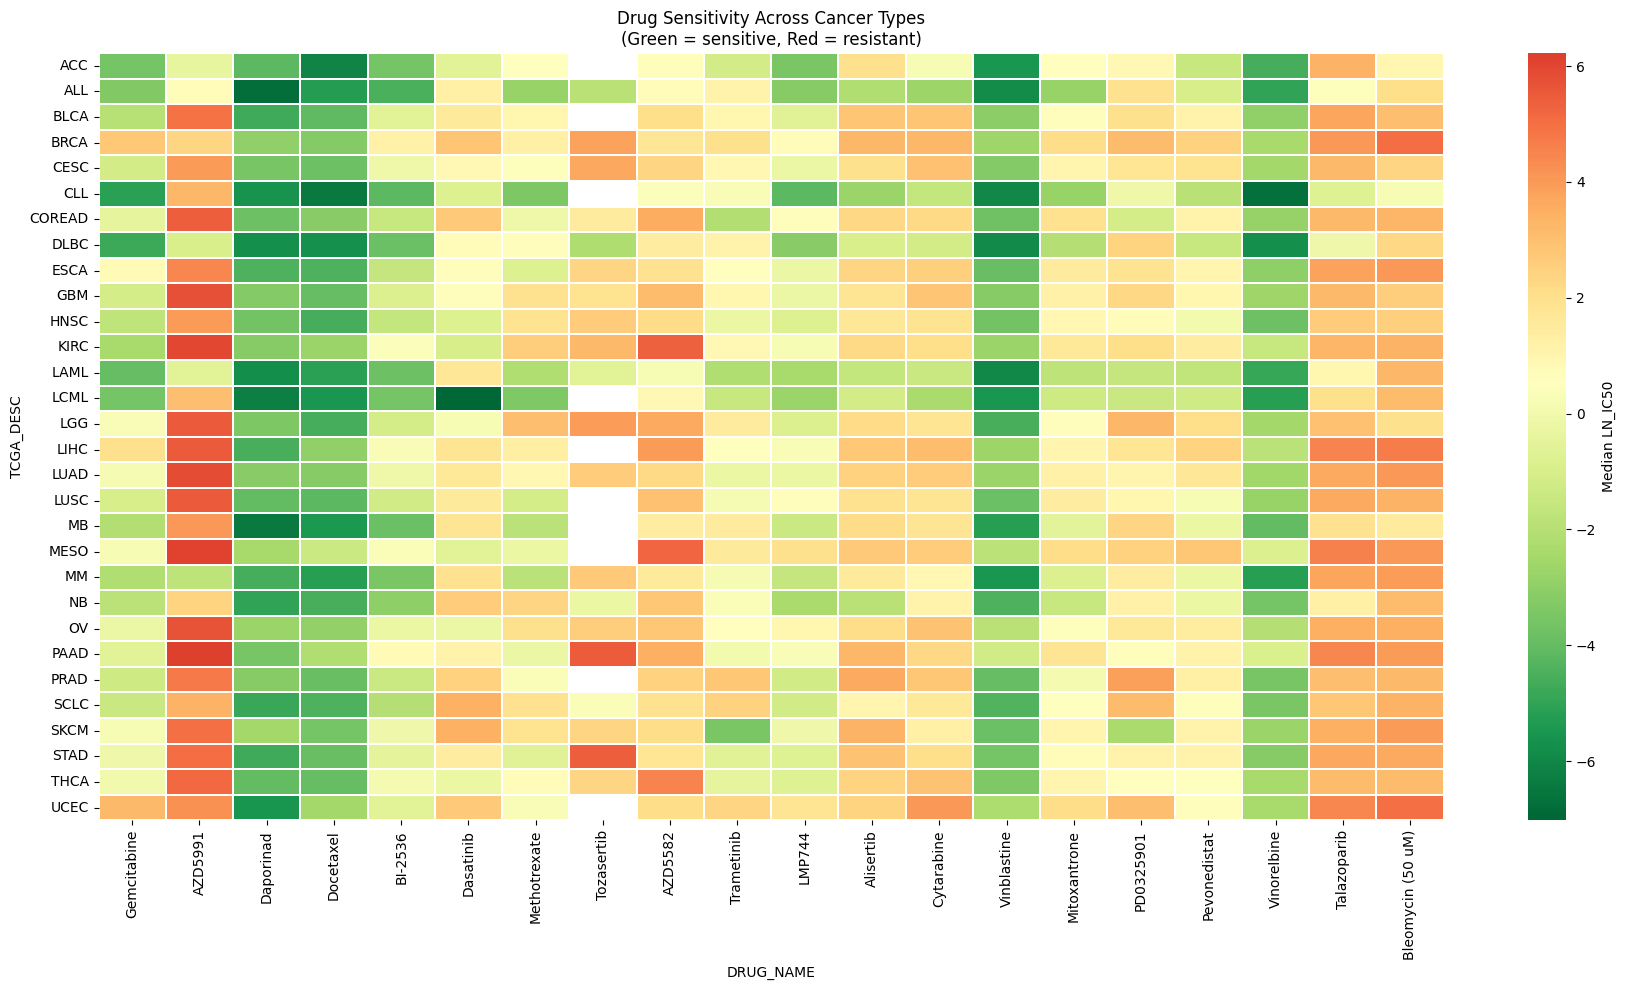

In [31]:
# Generate visualization for exploratory data analysis
pivot = (
    gdsc.groupby(["TCGA_DESC", "DRUG_NAME"])["LN_IC50"]
    .median()
    .unstack("DRUG_NAME")
)

# Optional: reduce to top variable drugs (important!)
top_drugs = gdsc.groupby("DRUG_NAME")["LN_IC50"].std().nlargest(20).index
pivot = pivot[top_drugs]

fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    center=pivot.stack().median(),
    linewidths=0.2,
    cbar_kws={"label": "Median LN_IC50"},
    ax=ax
)

ax.set_title("Drug Sensitivity Across Cancer Types\n(Green = sensitive, Red = resistant)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

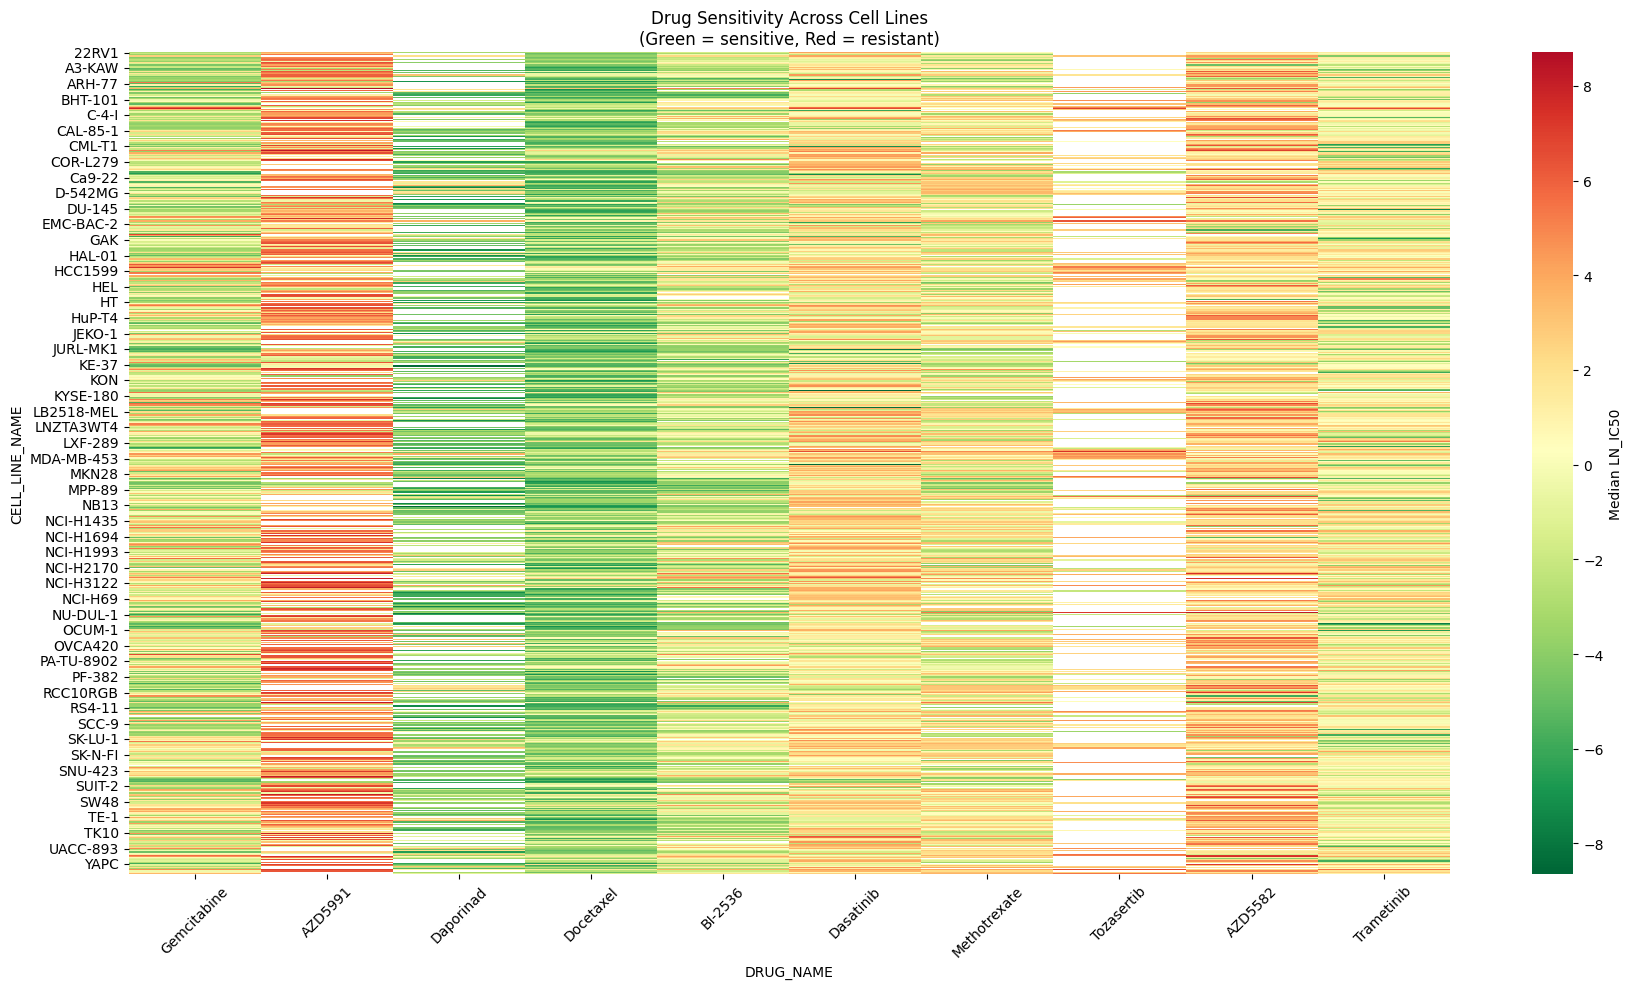

In [32]:
# Generate visualization for exploratory data analysis
pivot = (
    gdsc.groupby(["CELL_LINE_NAME", "DRUG_NAME"])["LN_IC50"]
    .median()
    .unstack("DRUG_NAME")
)

# Optional: reduce to top variable drugs (important!)
top_drugs = gdsc.groupby("DRUG_NAME")["LN_IC50"].std().nlargest(10).index
pivot = pivot[top_drugs]

fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    center=pivot.stack().median(),
    linewidths=0,
    cbar_kws={"label": "Median LN_IC50"},
    ax=ax
)

ax.set_title("Drug Sensitivity Across Cell Lines\n(Green = sensitive, Red = resistant)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Genomic, Transcriptomic, and Epigenomic Influence on Drug Response

In [33]:
genomic_flags = ["CNA", "Gene Expression", "Methylation", "Microsatellite instability Status (MSI)"]
sensitivity_metrics = ["LN_IC50", "AUC", "Z_SCORE"]

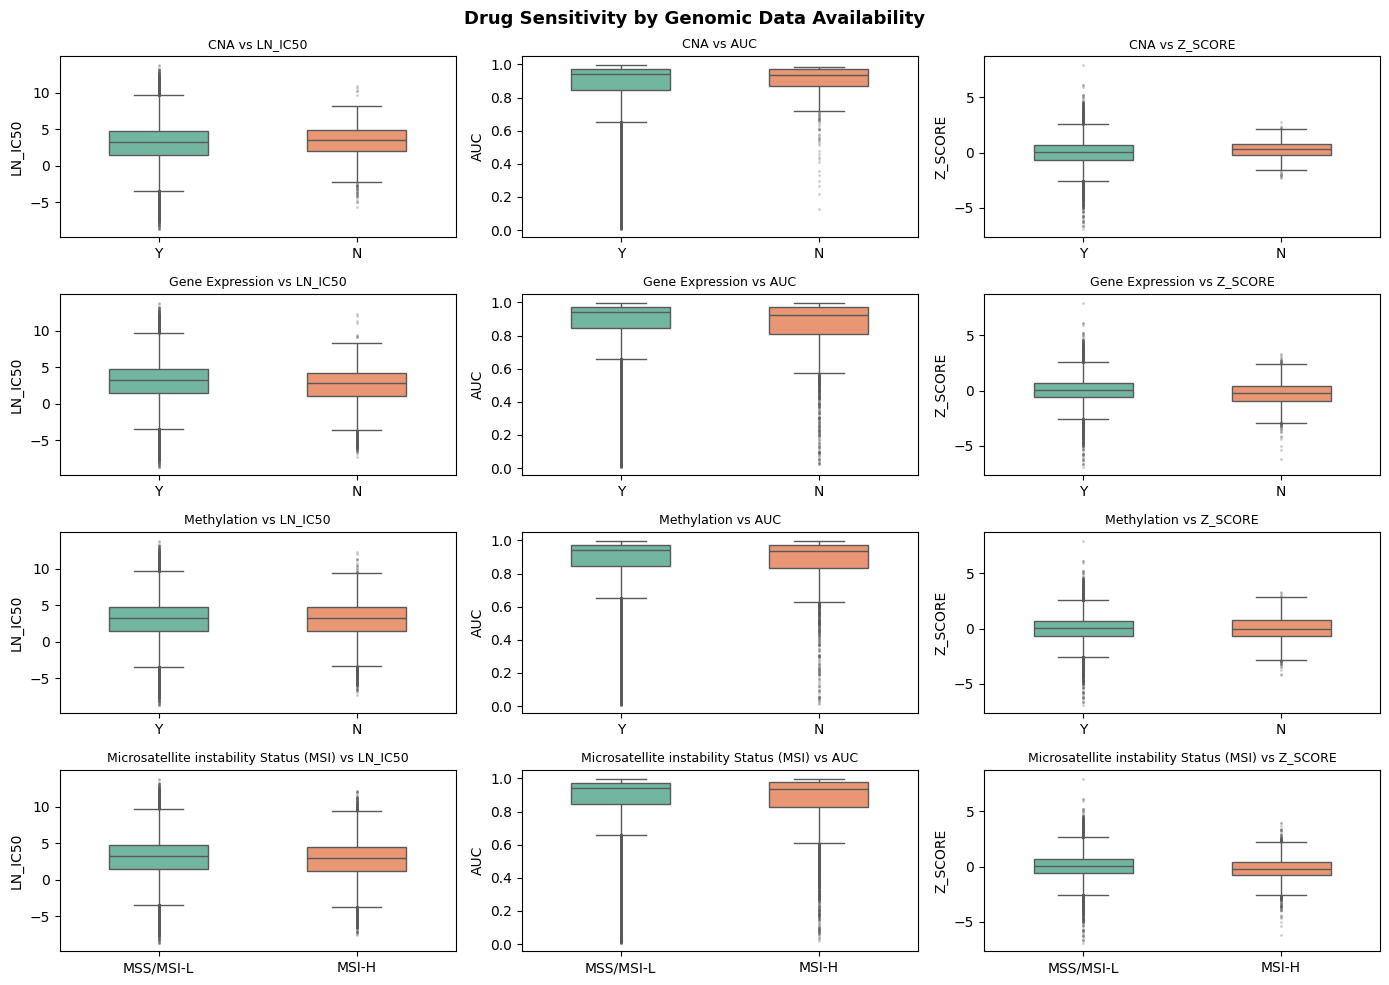

In [34]:
# Generate visualization for exploratory data analysis
fig, axes = plt.subplots(len(genomic_flags), len(sensitivity_metrics), figsize=(14, 10))

for i, flag in enumerate(genomic_flags):
    for j, metric in enumerate(sensitivity_metrics):
        ax = axes[i][j]
        sns.boxplot(data=gdsc, x=flag, y=metric, hue=flag, palette="Set2",legend=False,
                    width=0.5, flierprops=dict(marker=".", markersize=2, alpha=0.3), ax=ax)
        ax.set_title(f"{flag} vs {metric}", fontsize=9)
        ax.set_xlabel("")

plt.suptitle("Drug Sensitivity by Genomic Data Availability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("genomic_flags_vs_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# Import required libraries
# ttest_ind → used to compare means between two independent groups
# pandas → for data manipulation and DataFrame creation
from scipy.stats import ttest_ind

# Initialize a list to store results for each drug
# Each entry will contain statistical test results for multiple genomic features
results = []

# Define genomic/epigenomic features to test
# These represent biological factors that may influence drug response
features = ["CNA", "Gene Expression", "Methylation"]

# Loop through each unique drug in the dataset
for drug in gdsc["DRUG_NAME"].unique():
    
    # Subset data for the current drug
    subset = gdsc[gdsc["DRUG_NAME"] == drug]
    
    # Initialize a dictionary to store results for this drug
    # Will hold p-values and mean differences for each feature
    drug_result = {"DRUG_NAME": drug}
    
    # Loop through each genomic feature
    for feature in features:
        
        # Check if the feature has at least two groups (e.g., Yes/No, 0/1)
        # If not, statistical comparison is not possible
        if subset[feature].nunique() < 2:
            drug_result[feature + "_p"] = None      # No p-value available
            drug_result[feature + "_diff"] = None   # No difference calculated
            continue
        
        # Get the unique groups for the feature (e.g., mutated vs not mutated)
        groups = subset[feature].unique()
        
        # Split LN_IC50 values into two groups based on feature status
        # g1 and g2 represent two biological conditions
        g1 = subset[subset[feature] == groups[0]]["LN_IC50"]
        g2 = subset[subset[feature] == groups[1]]["LN_IC50"]
        
        # Compute the difference in mean drug response between the two groups
        # Positive/negative value indicates direction of effect
        diff = g1.mean() - g2.mean()
        
        # Perform independent t-test to check if the difference is statistically significant
        # stat → t-statistic
        # p → p-value (probability that observed difference is due to chance)
        stat, p = ttest_ind(g1, g2)
        
        # Store results:
        # diff → magnitude and direction of effect
        # p → statistical significance
        drug_result[feature + "_diff"] = diff
        drug_result[feature + "_p"] = p
    
    # Append results for this drug to the main results list
    results.append(drug_result)

# Convert the list of dictionaries into a DataFrame
# Each row represents a drug, with columns for each feature's statistics
multi_feature_df = pd.DataFrame(results)

# Preview the results
multi_feature_df.head()

,DRUG_NAME,CNA_diff,CNA_p,Gene Expression_diff,Gene Expression_p,Methylation_diff,Methylation_p
0,Camptothecin,0.481560,0.646084,0.320857,0.423930,0.152597,0.724269
1,Vinblastine,-0.795814,0.609865,-0.743470,0.735851,0.283926,0.734554
2,Cisplatin,-0.319934,0.802164,-2.172698,0.228258,-0.654884,0.307297
3,Cytarabine,-2.512486,0.111784,1.996983,0.371401,0.848055,0.317730
4,Docetaxel,-1.023860,0.369877,1.426749,0.010859,0.111533,0.831845


In [36]:
# Filter the DataFrame to identify drugs that show a statistically significant association with at least one genomic feature
significant = multi_feature_df[
    (multi_feature_df["CNA_p"] < 0.05) |
    (multi_feature_df["Gene Expression_p"] < 0.05) |
    (multi_feature_df["Methylation_p"] < 0.05)
]

significant.head(20)

,DRUG_NAME,CNA_diff,CNA_p,Gene Expression_diff,Gene Expression_p,Methylation_diff,Methylation_p
4,Docetaxel,-1.023860,0.369877,1.426749,0.010859,0.111533,0.831845
5,Methotrexate,-1.310892,0.343414,-2.011790,0.000136,-1.390611,0.017703
9,Vorinostat,-0.382679,0.552080,0.533026,0.030215,-0.080198,0.768948
22,Tanespimycin,-2.338628,0.010089,-0.085285,0.806805,-0.147167,0.695399
31,NU7441,0.619786,0.431575,0.812119,0.006970,0.112267,0.729932
33,Doramapimod,0.280654,0.679729,1.097585,0.000022,0.463465,0.098138
34,JNK Inhibitor VIII,0.262754,0.637561,0.569906,0.008977,0.198982,0.387102
35,Wee1 Inhibitor,-0.597500,0.504809,0.822183,0.016301,0.417657,0.271652
37,Mirin,-1.193844,0.076534,0.730921,0.005622,0.356240,0.227048
39,ZM447439,-0.043726,0.964654,1.119539,0.002951,-0.093848,0.817701


In [37]:
# Convert wide format → long format
volcano_data = []

features = ["CNA", "Gene Expression", "Methylation"]

for _, row in multi_feature_df.iterrows():
    for feature in features:
        volcano_data.append({
            "DRUG_NAME": row["DRUG_NAME"],
            "Feature": feature,
            "Effect_Size": row[feature + "_diff"],   # mean difference
            "p_value": row[feature + "_p"]
        })

volcano_df = pd.DataFrame(volcano_data)

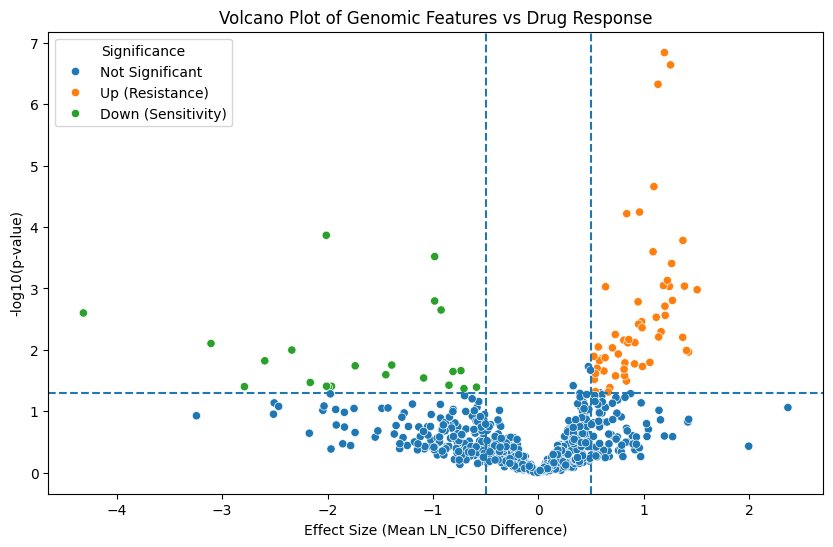

In [38]:
# Remove missing values
volcano_df = volcano_df.dropna()

# Convert p-values to -log10(p)
volcano_df["neg_log10_p"] = -np.log10(volcano_df["p_value"])

# Common thresholds
p_thresh = 0.05
effect_thresh = 0.5  # adjust based on your data

# Create significance labels
volcano_df["Significance"] = "Not Significant"

volcano_df.loc[
    (volcano_df["p_value"] < p_thresh) & 
    (volcano_df["Effect_Size"] > effect_thresh),
    "Significance"
] = "Up (Resistance)"

volcano_df.loc[
    (volcano_df["p_value"] < p_thresh) & 
    (volcano_df["Effect_Size"] < -effect_thresh),
    "Significance"
] = "Down (Sensitivity)"

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=volcano_df,
    x="Effect_Size",
    y="neg_log10_p",
    hue="Significance"
)

# Add threshold lines
plt.axhline(-np.log10(p_thresh), linestyle="--")  # p-value cutoff
plt.axvline(effect_thresh, linestyle="--")        # effect size cutoff
plt.axvline(-effect_thresh, linestyle="--")

plt.title("Volcano Plot of Genomic Features vs Drug Response")
plt.xlabel("Effect Size (Mean LN_IC50 Difference)")
plt.ylabel("-log10(p-value)")

plt.show()